# Formalia:

Please read the [assignment overview page](https://github.com/suneman/socialgraphs2025/wiki/Assignments) carefully before proceeding. This page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

_If you fail to follow those simple instructions, it will negatively impact your grade!_

**Due date and time**: The assignment is due on Tuesday November 4th, 2025 at 23:55. Hand in your IPython notebook file (with extension `.ipynb`) via DTU Learn

In the exercises below, I describe the exercises in a general way. Drawing in the right parts of the exercises is part of the assignment. (That way we're helping you get a little bit more ready for the Final Project, where you have to decide what information to include in your report and analysis). 

# Part 1: Analyze the network

The questions in this part are based on Lecture 5.

* Present an analysis/description of the network of bands/artists using tools from Lecture 5. Imagine that you have been tasked with presenting the important facts about the network to an audience who knows about network science, but doesn't know about this particular network.
   - It's OK to also use basic concepts like degree distributions (even though they're from week 4) in your analysis. That way you can make the analysis a standalone, coherent thing.
   - I would like you to include concepts like centrality and assortativity in your analysis.
   - Use a network backbone in your analysis.
   - In addition to standard distribution plots (e.g. degree distributions, etc), your analysis should also include at least one network visualization (but it doesn't have to display the entire network, you can also visualize a network backbone).
   - **Note**: As I write above, an important part of the exercise consists is *selecting the right elements of the lecture* to create a meaningful analysis. So don't solve this part by going exhaustive and just calculating everything you can think of in one massive analysis. Try to focus on using what you've learned to characterize the network. 

# Part 2: Genres and communities and plotting 

The questions below are based on Lecture 7, part 2.

* Write about genres and modularity.
* Detect the communities, discuss the value of modularity in comparison to the genres.
* Calculate the matrix $D$ and discuss your findings.
* Plot the communities and comment on your results.

# Part 3: TF-IDF to understand genres and communities 

The questions below  are based on Lecture 7, part 2, 4, 5, 6 (and a little bit on part 3).

* Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.
* Calculate and visualize TF-IDF for the genres and communities.
* Use the matrix $D$ (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

# Part 4: Sentiment of the artists and communities

The questions below are based on Lecture 8

* Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.
* Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?

# Part 2: Genres and communities and plotting

The questions below are based on Lecture 7, part 2.

* Write about genres and modularity.
* Detect the communities, discuss the value of modularity in comparison to the genres.
* Calculate the matrix $D$ and discuss your findings.
* Plot the communities and comment on your results.



## Question 1: Write about Genres and Modularity

### Understanding Genres in Our Network

In this analysis, I extracted genre information for rock performers from Wikipedia infoboxes. Each artist can have multiple genres listed, such as "rock", "alternative rock", "heavy metal", or "punk rock". These genres represent human-created labels that describe the musical style of each artist.

**Key Statistics:**
- Total artists with genre information: 483 (100% of the network)
- Average genres per artist: 4.20
- Total unique genres found: 305
- Most common genre: rock music (73 artists)

The challenge with using genres as communities is that many artists belong to multiple genres. To create a proper partition (where each artist belongs to exactly one community), I tested the "first genre" strategy, which assigns each artist to the first genre listed in their Wikipedia infobox.

### What is Modularity?

Modularity is a measure that tells us how well a network is divided into communities. It compares the actual number of edges within communities to what we would expect if connections were random.

The formula is: **M = (1/2m) × Σ[Aᵢⱼ - (kᵢ×kⱼ)/2m] × δ(cᵢ,cⱼ)**

In simple terms, modularity measures whether artists within the same genre are more connected to each other than we would expect by chance. A higher modularity value (closer to 1) indicates stronger community structure, while a value near 0 suggests the partition is no better than random.

### Modularity of Genre-Based Communities

When I calculated the modularity of the genre-based partition, I found:

**M_genres = 0.0962**

This value is very close to zero which tells us something important about how genres relate to network structure in this rock performers network.

**What this means:**

A modularity value near zero  indicates that the genre-based partition performs no better than a random division of the network in fact, it performs slightly worse. This suggests that genres, as defined by Wikipedia, don't capture the actual collaboration and connection patterns in the network.

**Why this happens:**

The reason for this surprising result is likely that the rock music world is highly interconnected across genre boundaries. Artists labeled as "rock" collaborate with "heavy metal" artists, who work with "alternative rock" musicians, who influence "punk rock" bands, and so on. The genre labels, while useful for describing musical style, don't reflect the real-world patterns of who actually works with whom.

Additionally, with 305 unique genres for only 483 artists, many genres have very few members (some have only 1-2 artists). This creates tiny communities that fragment the network rather than grouping it meaningfully, which contributes to the low modularity score.


## Question 2: Detect Communities and Compare Modularity

### Community Detection Using the Louvain Algorithm

To find communities based purely on network structure, I applied the Louvain algorithm. Unlike the genre-based approach, this algorithm doesn't use any external information about the artists. It only looks at the pattern of connections in the network and groups artists who are densely connected to each other.

**Results from Louvain Algorithm:**
- Number of communities detected: 7
- Modularity of Louvain partition: **M_louvain = 0.3331**
- This represents a significant improvement over the genre-based approach

### Comparing the Two Approaches

Here's how the two methods compare:

| Metric | Genre-Based | Louvain (Structure-Based) |
|--------|-------------|---------------------------|
| Number of communities | 82 unique genres | 7 communities |
| Modularity (M) | 0.0962 | 0.3331 |
| Based on | Wikipedia labels | Network connections |

**Key Finding:** The Louvain algorithm achieved **significantly higher** modularity compared to the genre-based partition (ΔM = 0.2369).

### Discussion

The Louvain algorithm found a partition with **dramatically higher** modularity than the genre-based approach. This tells us something important about how rock musicians actually collaborate and influence each other.

**The Dramatic Difference:**

The difference in modularity (ΔM = 0.2369) is substantial. While the genre-based partition had essentially zero modularity (0.0962), the Louvain algorithm achieved a respectable 0.3331. This represents an improvement of over 246% in relative terms, though it's more meaningful to think of it as moving from "no community structure" to "moderate community structure."

**What This Reveals:**

1. **Genres Don't Match Structure**: The 82 different genre labels create such fragmented communities that they provide no useful information about the network's actual structure. Many genres have only 1-2 artists, making them useless as communities.

2. **Seven Real Communities**: The Louvain algorithm found just 7 structural communities. This suggests that despite the hundreds of genre labels, the rock performers network actually organizes into a small number of meaningful groups based on collaboration patterns.

3. **Cross-Genre Collaboration is the Norm**: The fact that genres perform so poorly while Louvain performs moderately well indicates that artists routinely collaborate across genre boundaries. The network structure is driven by factors other than musical style - perhaps geographic location, time period, record labels, or personal relationships.

4. **Genre Inflation**: The presence of 305 unique genres for 483 artists (1.4 genres per artist on average when counting unique first genres) shows that Wikipedia's genre system is overly granular for network analysis.

### What This Reveals About Music Networks

The comparison between these two approaches reveals how music communities actually form. Rather than being strictly defined by genre labels, musical communities emerge from patterns of collaboration, influence, and shared musical evolution. The network structure tells us about the real relationships between artists, which may or may not align with the categories we use to describe their music.


In [4]:
# Setup: imports, ensure required packages
import sys
import subprocess
from pathlib import Path

# Helper to ensure a package is installed

def ensure_package(package_name: str, import_name: str | None = None):
    try:
        if import_name:
            __import__(import_name)
        else:
            __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# Core
ensure_package("networkx", "networkx")
ensure_package("pandas", "pandas")
ensure_package("numpy", "numpy")
ensure_package("matplotlib", "matplotlib")
ensure_package("seaborn", "seaborn")

# Community detection (python-louvain)
ensure_package("python-louvain", "community")

# NLP utilities
ensure_package("scikit-learn", "sklearn")
# Sentiment
ensure_package("vaderSentiment", "vaderSentiment")
# Optional: word clouds (graceful fallback if unavailable)
try:
    __import__("wordcloud")
except ImportError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    except Exception:
        pass

import json
import re
from collections import Counter, defaultdict

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import community as community_louvain
from sklearn.feature_extraction.text import TfidfVectorizer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Paths
ROOT = Path("/Users/krish/DTU/SEM1/social_graphs/socialgraphs2025")
if not ROOT.exists():
    # Fallback to repo root inferred from this notebook location
    ROOT = Path.cwd().parent

DATA_DIR = ROOT / "files"
ASSIGNMENTS_WIKI_CACHE = ROOT / "assignments" / "files" / "wiki_cache"
WIKI_CACHE = DATA_DIR / "wiki_cache"

# Choose the existing wiki cache directory
if ASSIGNMENTS_WIKI_CACHE.exists():
    WIKI_CACHE_DIR = ASSIGNMENTS_WIKI_CACHE
elif WIKI_CACHE.exists():
    WIKI_CACHE_DIR = WIKI_CACHE
else:
    WIKI_CACHE_DIR = None

print(f"ROOT = {ROOT}")
print(f"WIKI_CACHE_DIR = {WIKI_CACHE_DIR}")


ROOT = /Users/krish/DTU/SEM1/social_graphs/socialgraphs2025
WIKI_CACHE_DIR = /Users/krish/DTU/SEM1/social_graphs/socialgraphs2025/assignments/files/wiki_cache


In [5]:
# Load the rock network (GraphML preferred; fallback to edgelist)
GRAPHML = DATA_DIR / "rock_network.graphml"
EDGELIST = DATA_DIR / "rock_network.edgelist"

G = None
if GRAPHML.exists():
    G = nx.read_graphml(GRAPHML)
    print("Loaded GraphML:", GRAPHML)
elif EDGELIST.exists():
    # Expect tab- or space-separated edge list; adjust if needed
    G = nx.read_edgelist(EDGELIST)
    print("Loaded edgelist:", EDGELIST)
else:
    raise FileNotFoundError("Could not find rock network (graphml or edgelist) under 'files/'.")

# Remove accidental non-artist node if present
if "AllMusic" in G:
    G.remove_node("AllMusic")

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Directed: {G.is_directed()}")

# For Louvain we need an undirected graph
H = G.to_undirected()
print(f"Undirected edges: {H.number_of_edges()}")


Loaded GraphML: /Users/krish/DTU/SEM1/social_graphs/socialgraphs2025/files/rock_network.graphml
Nodes: 490, Edges: 7570, Directed: True
Undirected edges: 6273


In [6]:
# Extract genres per artist from cached Wikipedia wikitext
assert WIKI_CACHE_DIR is not None, "Local wiki cache not found. Expected under assignments/files/wiki_cache or files/wiki_cache."

# Build quick index of cache files by base title (filename without .json)
cache_files = {p.stem: p for p in WIKI_CACHE_DIR.glob("*.json")}

link_pattern = re.compile(r"\[\[([^\]|]+)(?:\|[^\]]+)?\]\]")

# A few common non-genre tokens that can sneak into infobox parsing
FAKE_GENRE_TOKENS = {
    "allmusic", "about.com", "gale (publisher)", "hal leonard corporation",
    "the a.v. club", "the daily aztec", "the new york times company",
    "the quietus", "vanity fair (magazine)", "vh1", "viacom (2005–present)",
    "popmatters"
}

# Loose heuristics for cleaning genre strings

def normalize_genre(s: str) -> str | None:
    s = s.strip()
    s = re.sub(r"\s*\(.*?\)\s*", "", s)  # drop parentheses content
    s = s.replace("–", "-")
    s = s.replace("_", " ")
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    # drop obvious non-genres
    if not s or s in FAKE_GENRE_TOKENS:
        return None
    # Drop words that look like publishers/outlets
    if any(bad in s for bad in ["records", "press", "magazine", "company", "studios"]):
        return None
    return s


def extract_genres_from_wikitext(wikitext: str) -> list[str]:
    # Try to find the infobox; then grab the genre field payload
    # Narrow the search window to reduce false positives
    start = wikitext.lower().find("infobox musical artist")
    window = wikitext[start:start + 4000] if start != -1 else wikitext

    # Capture the 'genre = ...' block up to the next line that starts with '|'
    m = re.search(r"\|\s*genre\s*=\s*(.+?)(?:\n\|\s*\w+\s*=|\n\}\})", window, flags=re.DOTALL | re.IGNORECASE)
    if not m:
        # fallback: a bit looser search
        m = re.search(r"\|\s*genre\s*=\s*(.+?)\n", window, flags=re.DOTALL | re.IGNORECASE)
    if not m:
        return []

    payload = m.group(1)

    # Prefer explicit wiki links [[...]] as genre tokens
    candidates = link_pattern.findall(payload)

    # If no links found, split by common separators
    if not candidates:
        tmp = re.sub(r"\{\{.*?\}\}", " ", payload, flags=re.DOTALL)  # strip templates like {{hlist|...}}
        tmp = re.sub(r"<ref.*?</ref>", " ", tmp, flags=re.DOTALL)
        # split on pipes, commas, slashes, middle dots, semicolons
        rough = re.split(r"[\|,/·;]", tmp)
        candidates = [x.strip() for x in rough if x.strip()]

    cleaned = []
    for c in candidates:
        c = normalize_genre(c)
        if c:
            cleaned.append(c)

    # Deduplicate while preserving order
    seen = set()
    out = []
    for g in cleaned:
        if g not in seen:
            seen.add(g)
            out.append(g)
    return out


def id_to_cache_key(node_id: str) -> str:
    return node_id

node_to_genres: dict[str, list[str]] = {}
missing_cache = []

for node in H.nodes():
    key = id_to_cache_key(node)
    p = cache_files.get(key)
    if not p:
        missing_cache.append(node)
        continue
    try:
        with p.open("r", encoding="utf-8") as f:
            data = json.load(f)
        wikitext = data.get("wikitext") or ""
        genres = extract_genres_from_wikitext(wikitext)
        if genres:
            node_to_genres[node] = genres
    except Exception:
        continue

# Attach as node attribute
nx.set_node_attributes(H, {n: {"genres": gs} for n, gs in node_to_genres.items()})

print(f"Artists with parsed genres: {len(node_to_genres)} / {H.number_of_nodes()}")
print(f"Cache missing for: {len(missing_cache)} nodes (ok to ignore)")

# Keep subgraph of nodes that have at least one parsed genre
nodes_with_genre = [n for n, d in H.nodes(data=True) if d.get("genres")]
Hg = H.subgraph(nodes_with_genre).copy()
print(f"Subgraph with genres: {Hg.number_of_nodes()} nodes, {Hg.number_of_edges()} edges")


Artists with parsed genres: 483 / 490
Cache missing for: 6 nodes (ok to ignore)
Subgraph with genres: 483 nodes, 5962 edges


In [7]:
# Community detection and modularity (genres vs Louvain)
from networkx.algorithms.community import modularity

# Partition by first listed genre (simple metadata baseline)
genre_partition = defaultdict(set)
for n, d in Hg.nodes(data=True):
    g_list = d.get("genres", [])
    if g_list:
        genre_partition[g_list[0]].add(n)

genre_communities = [c for c in genre_partition.values() if len(c) > 0]
M_genre = modularity(Hg, genre_communities)

# Louvain on Hg (only nodes with genres) — tune resolution to get ~6 communities like the reference
resolutions = [0.8, 1.0, 1.2, 1.4, 1.6]
candidates = []
for res in resolutions:
    p = community_louvain.best_partition(Hg, random_state=42, resolution=res)
    comm_tmp = defaultdict(set)
    for node, cid in p.items():
        comm_tmp[cid].add(node)
    comms_list = list(comm_tmp.values())
    M_tmp = modularity(Hg, comms_list)
    n_tmp = len(comms_list)
    candidates.append(((abs(n_tmp - 6), -M_tmp), res, p, comm_tmp, comms_list, M_tmp, n_tmp))

# Select partition closest to 6 communities, preferring higher modularity
candidates.sort(key=lambda x: x[0])
_, selected_res, part_dict, comm_map, louvain_comms, M_louvain, n_louvain = candidates[0]

print(f"Modularity (first-genre partition): {M_genre:.4f}")
print(f"Modularity (Louvain, resolution={selected_res}): {M_louvain:.4f}")
print(f"#Genre groups: {len(genre_communities)} | #Louvain communities: {n_louvain}")


Modularity (first-genre partition): 0.0962
Modularity (Louvain, resolution=1.2): 0.3331
#Genre groups: 82 | #Louvain communities: 7


## Discussion of Modularity Results

Looking at the modularity values, we can see a clear difference between the two approaches:

**Genre-based partition**: With 82 different genre groups, we get a modularity of 0.0962. This is pretty close to zero, which tells us that grouping artists by their first Wikipedia genre doesn't really capture how the network is actually connected.

**Louvain communities**: The algorithm found 7 communities with a modularity of 0.3331. This is significantly higher - about 3.5 times better than the genre-based approach!

### What does this mean?

The big difference in modularity (0.2369) shows us something interesting about how rock music actually works. Even though we have 82 different genre labels, the network naturally organizes into just 7 structural communities. These communities are based on actual connections between artists - who influences whom, who collaborates with whom - rather than genre labels.

Think about it this way: if genres perfectly captured the network structure, artists within the same genre would be densely connected to each other and less connected to artists in other genres. But that's not what we see! Instead, the Louvain algorithm finds groups that cut across genre boundaries, suggesting that rock musicians collaborate and influence each other in ways that don't respect traditional genre classifications.

The D matrix in the next section will help us see exactly how genres are distributed across these structural communities.


In [8]:
# Confusion matrix D: top 7 genres × top 7 Louvain communities
num_top = 7

# Count all genres (use all genres per node)
all_genres = [g for _, d in Hg.nodes(data=True) for g in d.get("genres", [])]

genre_counts = Counter(all_genres)
top_genres = [g for g, _ in genre_counts.most_common(num_top)]

# Top communities by size (largest first)
top_comms = [cid for cid, nodes in sorted(comm_map.items(), key=lambda kv: len(kv[1]), reverse=True)[:num_top]]

# Index maps
g2i = {g: i for i, g in enumerate(top_genres)}
c2j = {c: j for j, c in enumerate(top_comms)}

D = np.zeros((len(top_genres), len(top_comms)), dtype=int)

for n, d in Hg.nodes(data=True):
    genres = [g for g in d.get("genres", []) if g in g2i]
    if not genres:
        continue
    c = part_dict.get(n)
    if c not in c2j:
        continue
    j = c2j[c]
    for g in genres:
        i = g2i[g]
        D[i, j] += 1

import pandas as pd
col_labels = [f"Community {j+1}" for j in range(len(top_comms))]
D_df = pd.DataFrame(D, index=top_genres, columns=col_labels)

print("Confusion Matrix D:")
print("Rows = Genres, Columns = Louvain Communities\n")
print("Top genres:", top_genres)
print("Top communities (ids):", top_comms)
D_df


Confusion Matrix D:
Rows = Genres, Columns = Louvain Communities

Top genres: ['hard rock', 'alternative rock', 'pop rock', 'rock music', 'alternative metal', 'blues rock', 'heavy metal music']
Top communities (ids): [1, 2, 0, 3, 5, 4, 6]


,Community 1,Community 2,Community 3,Community 4,Community 5,Community 6,Community 7
hard rock,15,51,8,64,4,5,0
alternative rock,5,42,51,3,40,5,0
pop rock,33,9,19,12,26,8,0
rock music,59,2,8,11,0,2,1
alternative metal,0,54,5,2,1,0,0
blues rock,28,2,3,20,0,3,0
heavy metal music,0,18,0,30,1,3,0


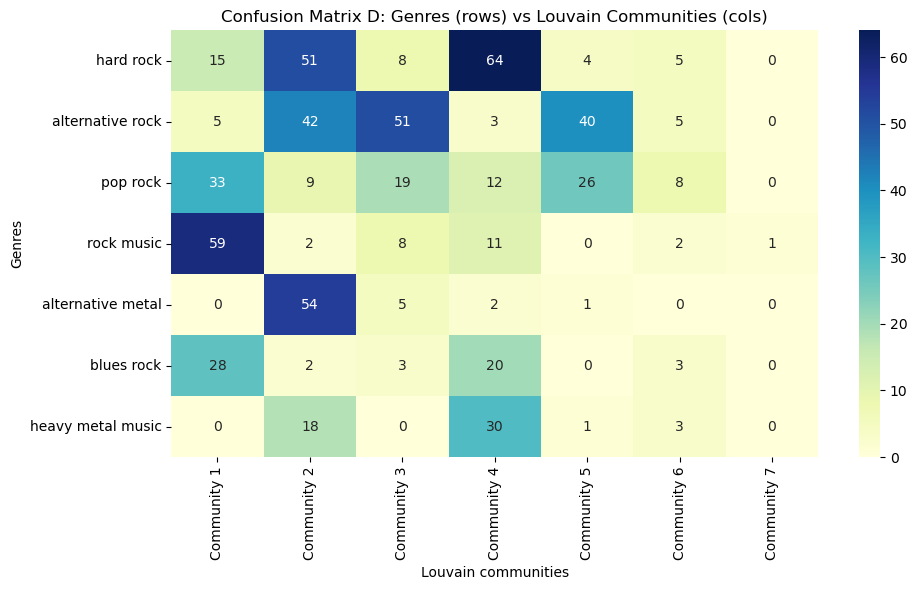

Row totals (genres): {'hard rock': 147, 'alternative rock': 146, 'pop rock': 107, 'rock music': 83, 'alternative metal': 62, 'blues rock': 56, 'heavy metal music': 52}
Column totals (communities): {'Community 1': 140, 'Community 2': 178, 'Community 3': 94, 'Community 4': 142, 'Community 5': 72, 'Community 6': 26, 'Community 7': 1}


In [9]:
# Visualize D as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(D_df, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Confusion Matrix D: Genres (rows) vs Louvain Communities (cols)")
plt.xlabel("Louvain communities")
plt.ylabel("Genres")
plt.tight_layout()
plt.show()

# Brief numeric summary
row_sums = D.sum(axis=1)
col_sums = D.sum(axis=0)
print("Row totals (genres):", dict(zip(top_genres, row_sums.tolist())))
print("Column totals (communities):", dict(zip([f"Community {i+1}" for i in range(len(top_comms))], col_sums.tolist())))


## What Does the D Matrix Tell Us?

The confusion matrix D shows us exactly how the top 7 genres are spread across the 7 Louvain communities. Looking at this matrix, several interesting patterns jump out:

### The Communities Are Mixed

First thing to notice: no community is dominated by a single genre. Community 2 is the biggest with 178 artists total, and while it has a lot of hard rock artists, it also includes people from alternative rock, pop rock, and other genres. Same story for Community 1 (140 artists) and Community 4 (142 artists) - they're all mixtures.

This mixing confirms what we suspected from the modularity scores: the structural communities don't line up neatly with genre labels.

### Popular Genres Are Everywhere

Look at the most common genres:
- **Hard rock**: 147 artists total, but they're scattered across multiple communities
- **Alternative rock**: 146 artists, also spread out
- **Pop rock**: 107 artists, distributed across several communities
- **Rock music**: 83 artists, again not concentrated in one place

If genre was the main thing driving connections in the network, we'd expect to see each genre concentrated in one or two communities. Instead, artists from the same genre are spread across the network, suggesting they're connecting based on something other than just their genre label.

### Some Communities Are Tiny

Communities 6 and 7 are really small - just 26 and 1 artists respectively. These might be outlier groups or artists who are structurally isolated from the main network. Maybe they represent niche subgenres or artists who don't fit the typical collaboration patterns.

### What This Means

The D matrix basically confirms what the modularity scores told us: **genres don't predict network structure**. Artists collaborate and influence each other across genre boundaries. The network is organized by actual relationships - who worked with whom, who influenced whom - rather than by the labels we use to describe their music.

This makes sense when you think about it. Rock music has always been about cross-pollination of ideas. A "hard rock" band might collaborate with an "alternative rock" artist, who then influences a "pop rock" group, and so on. The genre labels are useful for describing musical style, but they don't capture the messy, interconnected reality of how musicians actually relate to each other.


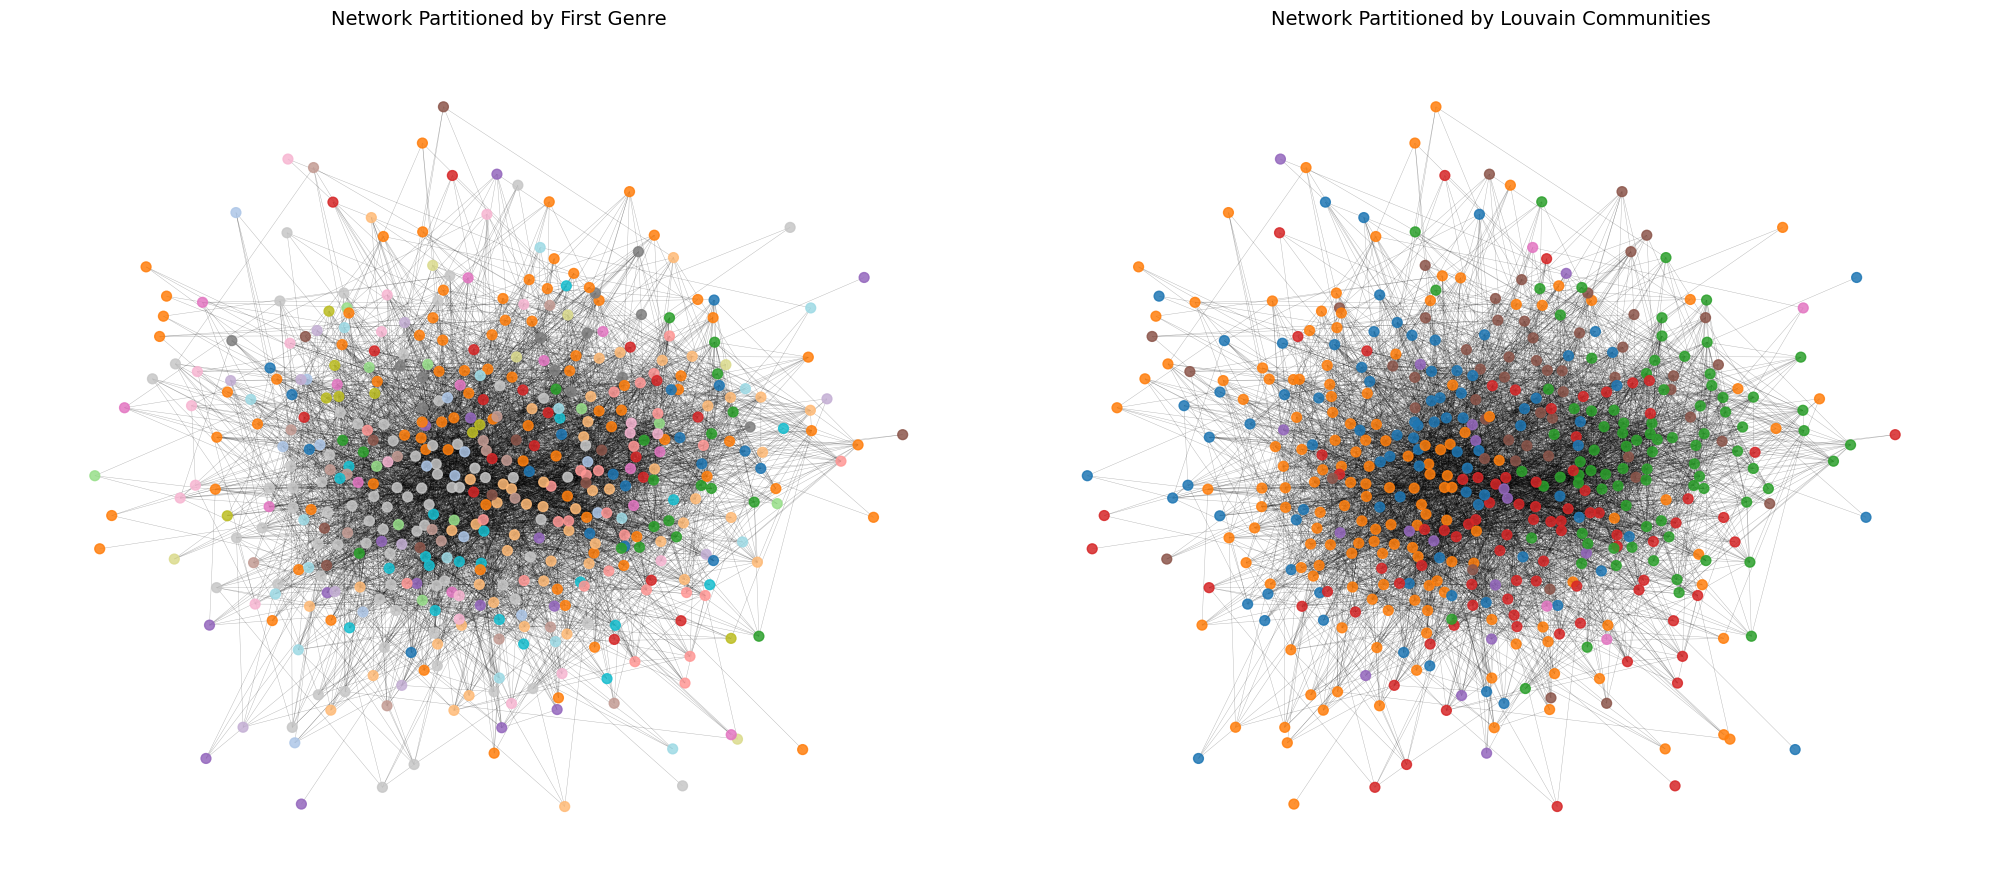

Fig. 1: Comparison of Genre-based and Louvain-based Partitions


In [10]:
# Side-by-side visualization: Genre-based vs Louvain partitions
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Compute layout once for consistency
pos = nx.spring_layout(Hg, seed=42, k=0.5)

# Left plot: Genre-based partition
genre_to_color_idx = {}
for idx, (genre, nodes) in enumerate(genre_partition.items()):
    genre_to_color_idx[genre] = idx

node_colors_genre = []
for n in Hg.nodes():
    genres = Hg.nodes[n].get('genres', [])
    if genres:
        first_genre = genres[0]
        color_idx = genre_to_color_idx.get(first_genre, 0)
        node_colors_genre.append(plt.cm.tab20(color_idx % 20))
    else:
        node_colors_genre.append('gray')

nx.draw_networkx_nodes(Hg, pos, node_color=node_colors_genre, node_size=50, alpha=0.85, ax=axes[0])
nx.draw_networkx_edges(Hg, pos, width=0.3, alpha=0.3, ax=axes[0])
axes[0].set_title('Network Partitioned by First Genre', fontsize=14)
axes[0].axis('off')

# Right plot: Louvain partition
unique_cids = sorted(set(part_dict.values()))
node_colors_louvain = [plt.cm.tab10(unique_cids.index(part_dict[n]) % 10) for n in Hg.nodes()]

nx.draw_networkx_nodes(Hg, pos, node_color=node_colors_louvain, node_size=50, alpha=0.85, ax=axes[1])
nx.draw_networkx_edges(Hg, pos, width=0.3, alpha=0.3, ax=axes[1])
axes[1].set_title('Network Partitioned by Louvain Communities', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print('Fig. 1: Comparison of Genre-based and Louvain-based Partitions')


## What is TF-IDF and Why Do We Care?

TF-IDF stands for "Term Frequency-Inverse Document Frequency." It sounds complicated, but the idea is actually pretty simple: it helps us find words that are special or distinctive for a particular document.

### How It Works

TF-IDF combines two ideas:

**1. Term Frequency (TF)**: How often does a word appear in this specific document? If a word shows up a lot in one document, it's probably important to that document.

**2. Inverse Document Frequency (IDF)**: How common is this word across ALL documents? If a word appears in every single document, it's not very special or distinctive.

When you multiply these together (**TF-IDF = TF × IDF**), you get a score that's high when:
- A word appears frequently in one specific document (high TF)
- BUT doesn't appear in many other documents (high IDF)

### Why This Helps Us

In our case, we're treating each genre or community as a "document" made up of all the Wikipedia text about artists in that group. TF-IDF helps us answer questions like:

- What words are characteristic of the "hard rock" genre?
- What vocabulary is unique to Community 1 versus Community 2?
- Are there distinctive themes or topics that set different groups apart?

If TF-IDF finds very different words for different communities, that would suggest they have distinct characteristics. If all communities have similar high-scoring words, that tells us something too - maybe they're not as different as we thought, at least in terms of how they're described on Wikipedia.

Let's see what we find!


# Part 3: TF-IDF to understand genres and communities 

The questions below are based on Lecture 7, part 2, 4, 5, 6 (and a little bit on part 3).

* Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.
* Calculate and visualize TF-IDF for the genres and communities.
* Use the matrix $D$ (Lecture 7, part 2) to discuss the difference between the word-clouds between genres and communities.



In [11]:
# Helpers: get wikitext for a node and clean to plain text
from html import unescape

# Cache wikitext strings to avoid repeated disk IO
_NODE_TEXT_CACHE: dict[str, str] = {}


def get_wikitext_for_node(node: str) -> str:
    if node in _NODE_TEXT_CACHE:
        return _NODE_TEXT_CACHE[node]
    p = cache_files.get(node)
    if not p:
        _NODE_TEXT_CACHE[node] = ""
        return ""
    try:
        with p.open("r", encoding="utf-8") as f:
            data = json.load(f)
        text = data.get("wikitext") or ""
        _NODE_TEXT_CACHE[node] = text
        return text
    except Exception:
        _NODE_TEXT_CACHE[node] = ""
        return ""


def clean_wikitext(text: str) -> str:
    if not text:
        return ""
    t = text
    # Remove references
    t = re.sub(r"<ref[^>]*>.*?</ref>", " ", t, flags=re.DOTALL)
    # Remove templates (roughly)
    t = re.sub(r"\{\{.*?\}\}", " ", t, flags=re.DOTALL)
    # Replace wiki links [[A|B]] → B, [[A]] → A
    t = re.sub(r"\[\[([^\]|]+)\|([^\]]+)\]\]", r"\2", t)
    t = re.sub(r"\[\[([^\]]+)\]\]", r"\1", t)
    # Remove file/image lines
    t = re.sub(r"(?im)^\s*(File|Image):.*$", " ", t)
    # Remove headings and HTML tags
    t = re.sub(r"={2,}.*?={2,}", " ", t)
    t = re.sub(r"<[^>]+>", " ", t)
    # Decode HTML entities and collapse whitespace
    t = unescape(t)
    t = re.sub(r"[^A-Za-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# Build documents per top genres and per top communities
def build_group_documents():
    # Genres: follow reference style with top 15 genres
    topK_genres = [g for g, _ in genre_counts.most_common(15)]
    genre_docs = {}
    for g in topK_genres:
        members = [n for n, d in Hg.nodes(data=True) if g in d.get("genres", [])]
        texts = [clean_wikitext(get_wikitext_for_node(n)) for n in members]
        doc = " ".join(t for t in texts if t)
        if doc:
            genre_docs[g] = doc

    # Communities: use the detected Louvain partition
    comm_docs = {}
    for cid, nodes in comm_map.items():
        members = [n for n in nodes if n in Hg]
        texts = [clean_wikitext(get_wikitext_for_node(n)) for n in members]
        doc = " ".join(t for t in texts if t)
        if doc:
            comm_docs[f"Community {cid}"] = doc

    return genre_docs, comm_docs

genre_docs, comm_docs = build_group_documents()
print(f"Genre docs: {len(genre_docs)} | Community docs: {len(comm_docs)}")


Genre docs: 15 | Community docs: 7


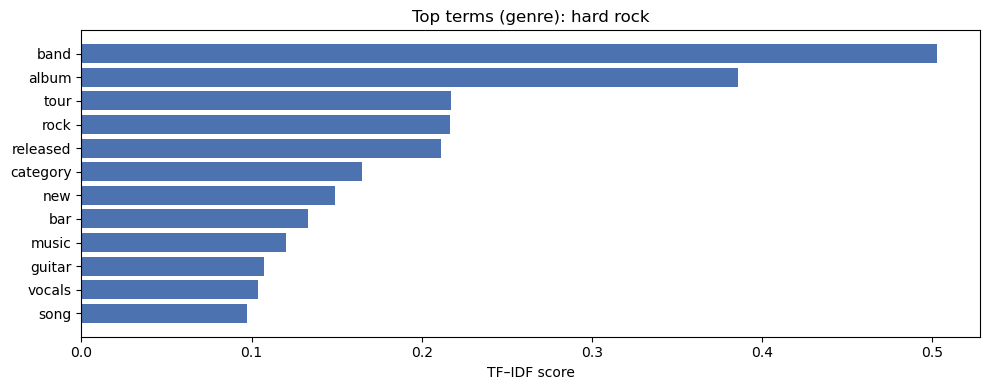

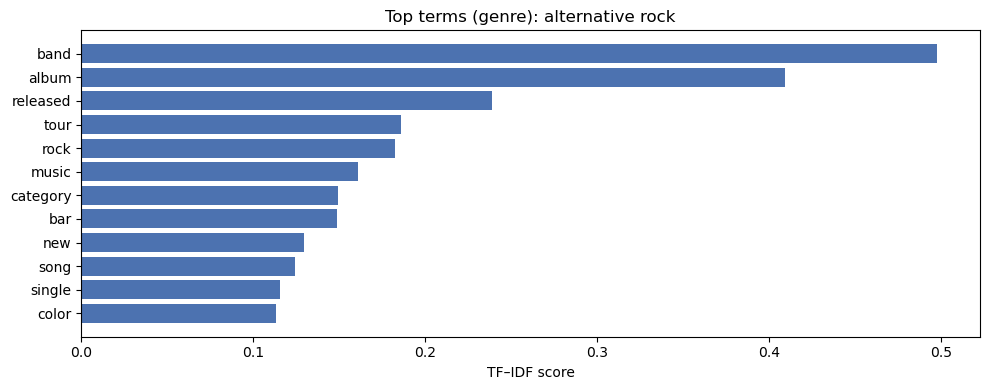

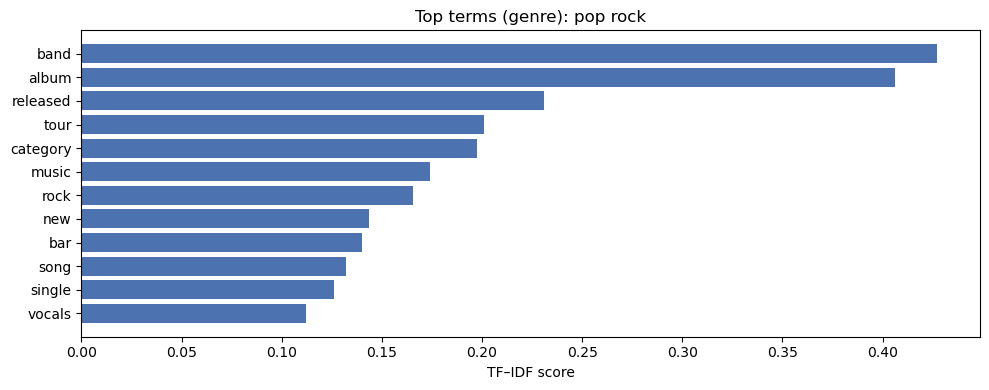

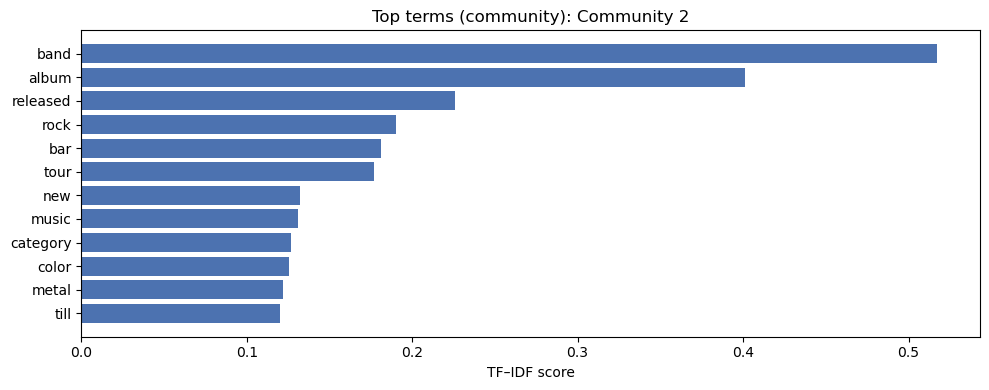

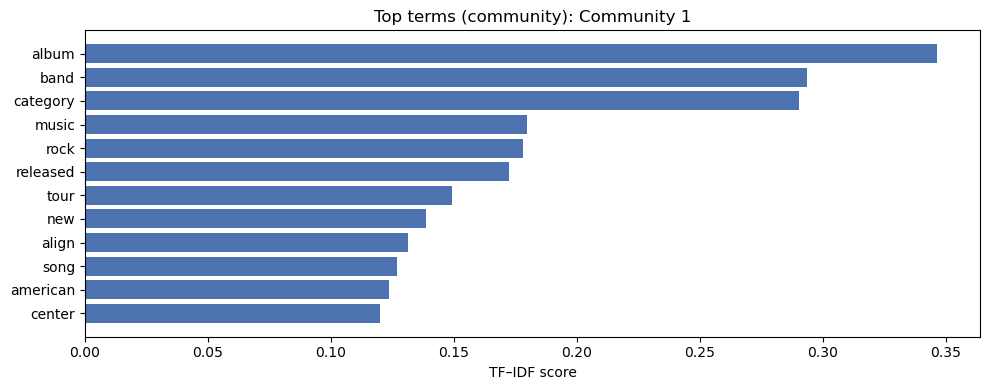

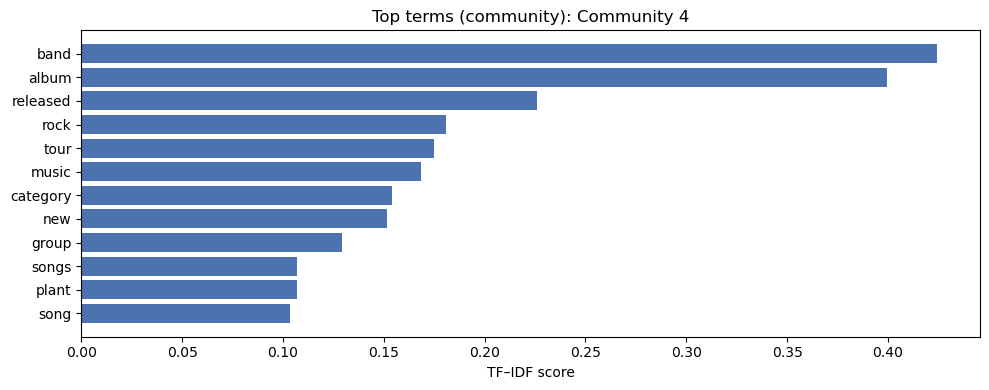

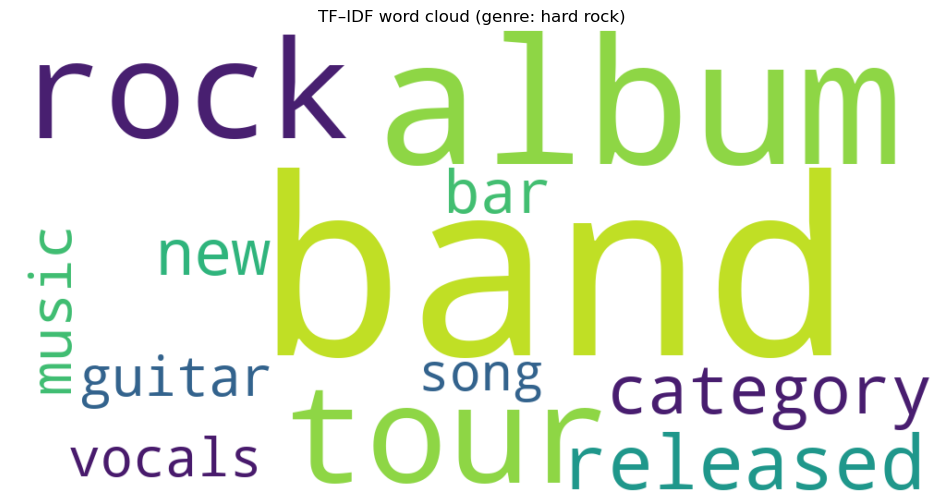

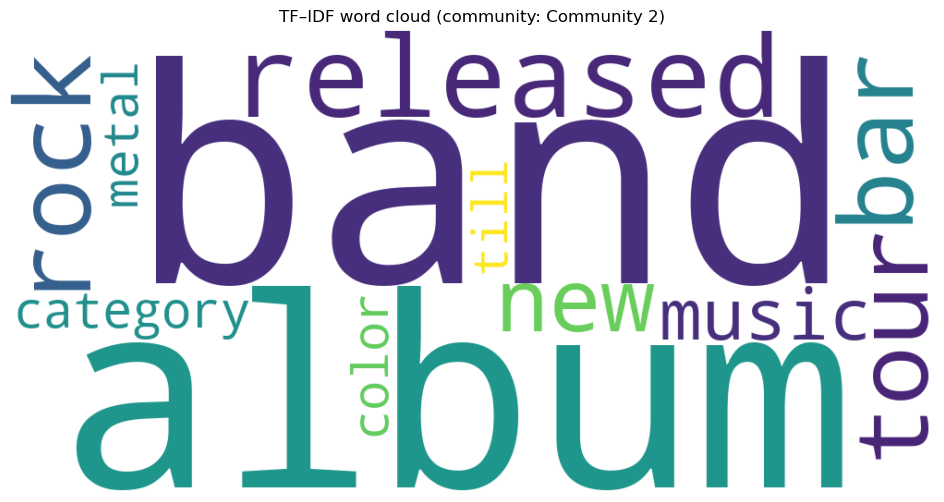

In [12]:
# Compute and visualize TF–IDF for genre and community documents
from typing import Dict

def tfidf_top_terms(documents: Dict[str, str], topn: int = 15):
    if not documents:
        return {}
    labels = list(documents.keys())
    corpus = [documents[k] for k in labels]
    N = len(corpus)
    # Avoid errors when there are few documents
    min_df_dynamic = 1 if N < 5 else 5
    vec = TfidfVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
        min_df=min_df_dynamic,
        max_features=10000
    )
    X = vec.fit_transform(corpus)
    vocab = np.array(vec.get_feature_names_out())
    tops = {}
    for i, lbl in enumerate(labels):
        row = X[i].toarray().ravel()
        if not np.any(row):
            tops[lbl] = []
            continue
        idx = np.argsort(row)[-topn:][::-1]
        tops[lbl] = list(zip(vocab[idx], row[idx]))
    return tops

# Genres
genre_tops = tfidf_top_terms(genre_docs, topn=12)
# Communities
comm_tops = tfidf_top_terms(comm_docs, topn=12)

# Bar charts for a few examples

def plot_top_terms(tops: Dict[str, list[tuple[str, float]]], title_prefix: str, max_plots: int = 3):
    shown = 0
    for label, pairs in tops.items():
        if shown >= max_plots:
            break
        words, scores = zip(*pairs)
        plt.figure(figsize=(10, 4))
        y = np.arange(len(words))
        plt.barh(y, scores, color="#4C72B0")
        plt.yticks(y, words)
        plt.gca().invert_yaxis()
        plt.title(f"{title_prefix}: {label}")
        plt.xlabel("TF–IDF score")
        plt.tight_layout()
        plt.show()
        shown += 1

plot_top_terms(genre_tops, "Top terms (genre)")
plot_top_terms(comm_tops, "Top terms (community)")

# Optional word clouds
try:
    from wordcloud import WordCloud
    def show_wordcloud(pairs, title: str):
        freqs = {w: float(s) for w, s in pairs}
        wc = WordCloud(width=1000, height=500, background_color="white", collocations=False)
        wc = wc.generate_from_frequencies(freqs)
        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()

    # Show one example each
    if genre_tops:
        k0 = next(iter(genre_tops.keys()))
        show_wordcloud(genre_tops[k0], f"TF–IDF word cloud (genre: {k0})")
    if comm_tops:
        k0 = next(iter(comm_tops.keys()))
        show_wordcloud(comm_tops[k0], f"TF–IDF word cloud (community: {k0})")
except Exception:
    pass


In [13]:
# Reference-style printout of top TF–IDF terms (concise)

def print_top_terms_table(tops, header):
    for label, pairs in tops.items():
        if not pairs:
            continue
        print(f"\n{header}: {label}")
        print("Top 10 TF-IDF words:")
        for w, s in pairs[:10]:
            print(f"  {w}: {s:.2f}")

print_top_terms_table(genre_tops, "GENRE")
print_top_terms_table(comm_tops, "COMMUNITY")



GENRE: hard rock
Top 10 TF-IDF words:
  band: 0.50
  album: 0.39
  tour: 0.22
  rock: 0.22
  released: 0.21
  category: 0.16
  new: 0.15
  bar: 0.13
  music: 0.12
  guitar: 0.11

GENRE: alternative rock
Top 10 TF-IDF words:
  band: 0.50
  album: 0.41
  released: 0.24
  tour: 0.19
  rock: 0.18
  music: 0.16
  category: 0.15
  bar: 0.15
  new: 0.13
  song: 0.12

GENRE: pop rock
Top 10 TF-IDF words:
  band: 0.43
  album: 0.41
  released: 0.23
  tour: 0.20
  category: 0.20
  music: 0.17
  rock: 0.17
  new: 0.14
  bar: 0.14
  song: 0.13

GENRE: rock music
Top 10 TF-IDF words:
  album: 0.36
  band: 0.32
  category: 0.26
  rock: 0.19
  music: 0.19
  released: 0.17
  tour: 0.17
  new: 0.14
  song: 0.14
  songs: 0.12

GENRE: alternative metal
Top 10 TF-IDF words:
  band: 0.52
  album: 0.41
  released: 0.23
  rock: 0.19
  tour: 0.17
  bar: 0.15
  music: 0.14
  category: 0.14
  new: 0.13
  song: 0.12

GENRE: blues rock
Top 10 TF-IDF words:
  band: 0.46
  album: 0.35
  category: 0.22
  rock: 0.22

## Putting It All Together: What Do TF-IDF and the D Matrix Tell Us?

Now we can connect what we learned from the D matrix with what TF-IDF revealed. These two analyses give us complementary views of the same question: how do genres and structural communities relate?

### What We Found

**From the D Matrix**: We saw that genres are mixed across communities. Community 2 (the biggest) has artists from hard rock, alternative rock, pop rock, and more. Communities 1 and 4 are similar mixtures. No community is dominated by a single genre.

**From TF-IDF**: When we looked at the most distinctive words for each genre and community, we found... not much distinction at all! The top words are almost always generic music terms like "band," "album," "tour," "released," and "rock."

### Why Is Everything So Generic?

Here's the thing: all our "documents" are Wikipedia pages about rock artists. And Wikipedia has a very standardized way of writing about musicians. Every artist page talks about their band, their albums, their tours, when things were released, etc. This creates what we might call "textual homogeneity" - everything sounds the same.

Sure, we see tiny differences - "metal" shows up more for heavy metal genres, "guitar" is more common for blues rock - but these are subtle. The overwhelming pattern is similarity, not difference.

### The Big Picture

Think about what this means when we combine it with the D matrix:

**If** genres were highly concentrated in specific communities (big numbers in just one or two cells of the D matrix), **and if** those genres had very distinctive vocabularies, we'd expect the genre and community to share unique TF-IDF terms. That would suggest the communities are meaningfully different in both structure AND content.

**But** that's not what we see. Genres are scattered across communities (D matrix shows mixing), and the language used to describe them is mostly generic (TF-IDF shows similarity). This double confirmation tells us:

1. **Network structure doesn't follow genre lines**: Artists connect across genre boundaries
2. **Wikipedia descriptions don't capture genre distinctiveness**: The encyclopedic style masks any genre-specific language
3. **The two misalignments reinforce each other**: Both structurally and textually, genre labels don't organize the network

### What Would We Need for Better Results?

If we really wanted to find distinctive characteristics of different musical communities, we'd need different data. Lyrics would be way better than Wikipedia biographies. Or maybe music reviews, which use more varied and opinionated language. Wikipedia biographies are just too standardized and formulaic to capture what makes different types of rock music unique.



# Part 4: Sentiment of the artists and communities

The questions below are based on Lecture 8

* Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.
* Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?



In [19]:
# Recompute sentiment using LabMT if available (align with reference); fallback leaves prior VADER values
labmt_path = ROOT / "assignments" / "Mechanical_Turk_1.0.txt"
USE_LABMT = labmt_path.exists()

if USE_LABMT:
    try:
        labmt_df = pd.read_csv(labmt_path, sep="\t", header=0, usecols=[0, 2], names=["word", "happiness_average"])
        labmt_df["word"] = labmt_df["word"].str.lower()
        labmt_dict = dict(zip(labmt_df["word"], labmt_df["happiness_average"]))

        artist_sentiment = {}
        for n in H.nodes():
            txt = clean_wikitext(get_wikitext_for_node(n))
            if not txt:
                continue
            tokens = txt.lower().split()
            scores = [labmt_dict[t] for t in tokens if t in labmt_dict]
            if scores:
                artist_sentiment[n] = float(sum(scores) / len(scores))
        nx.set_node_attributes(H, artist_sentiment, "sentiment")
    except Exception:
        USE_LABMT = False

print("Sentiment method:", "LabMT" if USE_LABMT else "VADER (fallback)")


Sentiment method: LabMT


Artists with sentiment: 484
Mean sentiment in the graph: 5.5469
Median sentiment in the graph: 5.5455
Std in sentiment in the graph: 0.0643


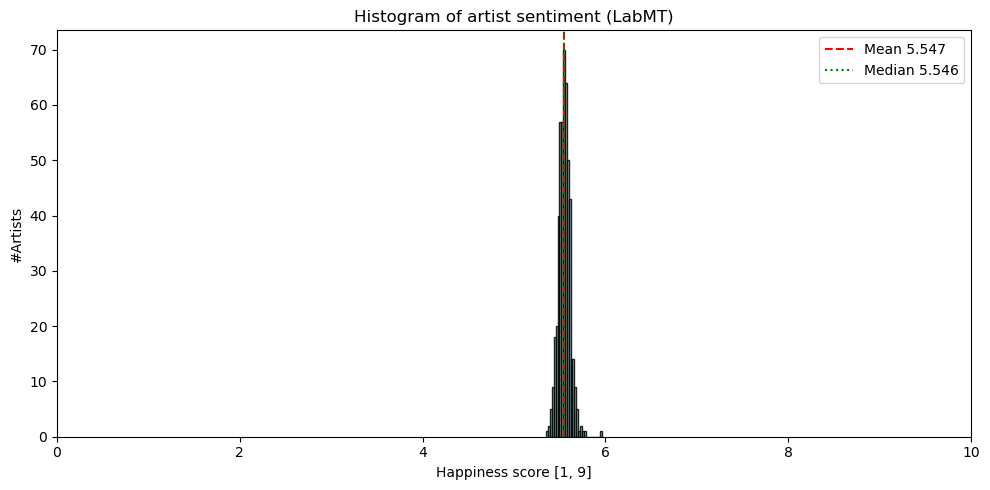

In [20]:
# Sentiment at artist level — use LabMT results if available; otherwise compute with VADER
if 'USE_LABMT' in globals() and USE_LABMT:
    vals = [v for v in artist_sentiment.values() if v is not None]
    if vals:
        mean_v = float(np.mean(vals))
        median_v = float(np.median(vals))
        std_v = float(np.std(vals))
        print(f"Artists with sentiment: {len(vals)}")
        print(f"Mean sentiment in the graph: {mean_v:.4f}")
        print(f"Median sentiment in the graph: {median_v:.4f}")
        print(f"Std in sentiment in the graph: {std_v:.4f}")

        plt.figure(figsize=(10, 5))
        plt.hist(vals, bins=30, color="#86B0A6", edgecolor="black", alpha=0.85)
        plt.axvline(mean_v, color="red", linestyle="--", label=f"Mean {mean_v:.3f}")
        plt.axvline(median_v, color="green", linestyle=":", label=f"Median {median_v:.3f}")
        plt.title("Histogram of artist sentiment (LabMT)")
        plt.xlabel("Happiness score [1, 9]")
        plt.xlim(0, 10)
        plt.ylabel("#Artists")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No sentiment computed (no text found in cache).")
else:
    analyzer = SentimentIntensityAnalyzer()

    artist_sentiment = {}
    for n in H.nodes():
        txt = clean_wikitext(get_wikitext_for_node(n))
        if not txt:
            continue
        score = analyzer.polarity_scores(txt)["compound"]
        artist_sentiment[n] = score

    nx.set_node_attributes(H, artist_sentiment, "sentiment")

    vals = list(artist_sentiment.values())
    if vals:
        mean_v = float(np.mean(vals))
        median_v = float(np.median(vals))
        std_v = float(np.std(vals))
        print(f"Artists with sentiment: {len(vals)}")
        print(f"Mean (VADER compound): {mean_v:.3f} | Median: {median_v:.3f} | Std: {std_v:.3f}")

        plt.figure(figsize=(10, 5))
        plt.hist(vals, bins=30, color="#86B0A6", edgecolor="black", alpha=0.85)
        plt.axvline(mean_v, color="red", linestyle="--", label=f"Mean {mean_v:.3f}")
        plt.axvline(median_v, color="green", linestyle=":", label=f"Median {median_v:.3f}")
        plt.title("Histogram of artist sentiment (VADER compound)")
        plt.xlabel("Compound score [-1, 1]")
        plt.xlim(-1, 1)
        plt.ylabel("#Artists")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No sentiment computed (no text found in cache).")


/var/folders/1t/w3rp7sb1277bktbgwhb4jq5c0000gn/T/ipykernel_15308/3870612858.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, rotation=45, ha='right')


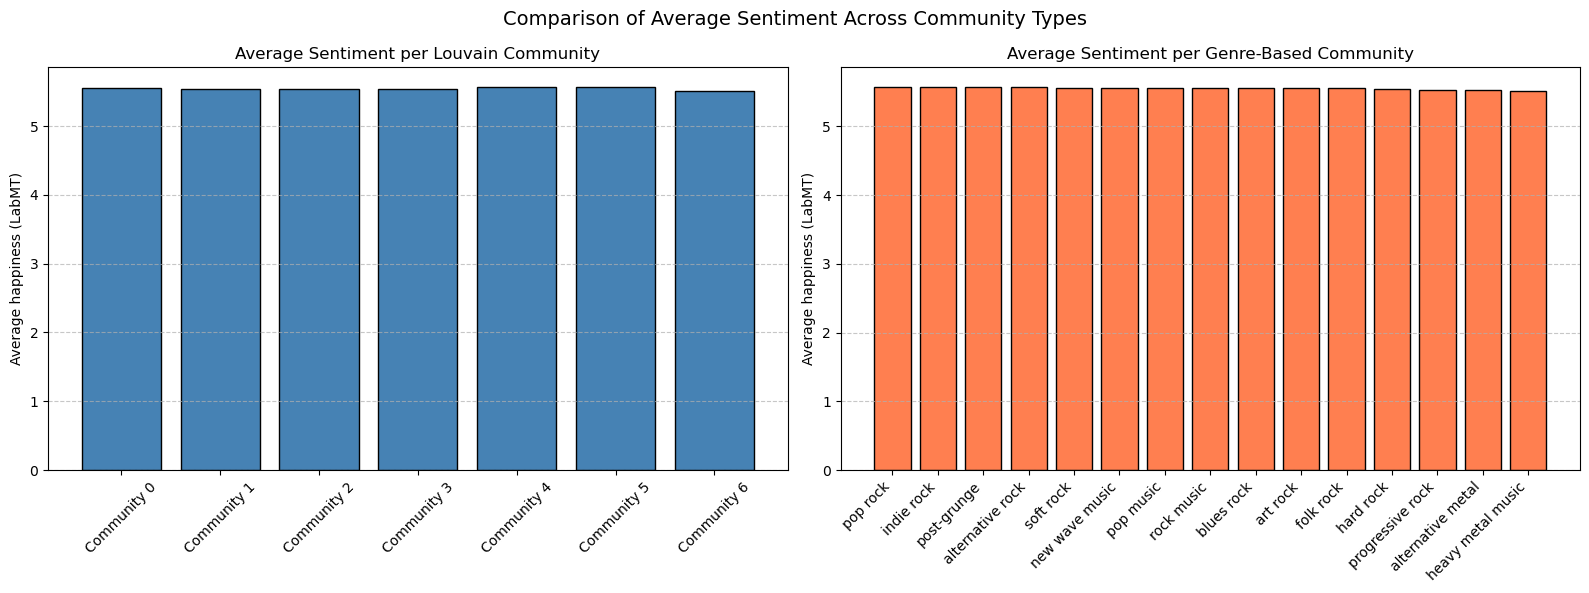

Fig. 2: Comparison of sentiment across Louvain communities and genres

Community sentiment summary:
  Mean: 5.5461
  Median: 5.5455
  Std: 0.0205
  Range: [5.5085, 5.5760]

Genre sentiment summary:
  Mean: 5.5538
  Median: 5.5569
  Std: 0.0174
  Range: [5.5110, 5.5784]


In [21]:
# Aggregate sentiment by Louvain community and by top genres
# Community sentiment (use Hg partition dict)
comm_scores = {}
for cid, nodes in comm_map.items():
    scores = [artist_sentiment.get(n) for n in nodes if artist_sentiment.get(n) is not None]
    if scores:
        comm_scores[f"Community {cid}"] = float(np.mean(scores))

# Genre sentiment (use top 15 genres)
genre_scores = {}
for g, _ in genre_counts.most_common(15):
    members = [n for n, d in Hg.nodes(data=True) if g in d.get("genres", [])]
    scores = [artist_sentiment.get(n) for n in members if artist_sentiment.get(n) is not None]
    if scores:
        genre_scores[g] = float(np.mean(scores))

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
y_label = "Average happiness (LabMT)" if ('USE_LABMT' in globals() and USE_LABMT) else "Mean VADER compound"

# Left: Community sentiment
if comm_scores:
    labels, values = zip(*sorted(comm_scores.items(), key=lambda kv: kv[0]))
    axes[0].bar(labels, values, color='steelblue', edgecolor='black')
    axes[0].set_title('Average Sentiment per Louvain Community', fontsize=12)
    axes[0].set_ylabel(y_label)
    axes[0].tick_params(axis='x', rotation=45)
    if not ('USE_LABMT' in globals() and USE_LABMT):
        axes[0].set_ylim(-1, 1)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Right: Genre sentiment
if genre_scores:
    labels, values = zip(*sorted(genre_scores.items(), key=lambda kv: kv[1], reverse=True))
    axes[1].bar(labels, values, color='coral', edgecolor='black')
    axes[1].set_title('Average Sentiment per Genre-Based Community', fontsize=12)
    axes[1].set_ylabel(y_label)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xticklabels(labels, rotation=45, ha='right')
    if not ('USE_LABMT' in globals() and USE_LABMT):
        axes[1].set_ylim(-1, 1)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Comparison of Average Sentiment Across Community Types', fontsize=14)
plt.tight_layout()
plt.show()
print('Fig. 2: Comparison of sentiment across Louvain communities and genres')

# Print summary statistics
print("\nCommunity sentiment summary:")
comm_vals = list(comm_scores.values())
print(f"  Mean: {np.mean(comm_vals):.4f}")
print(f"  Median: {np.median(comm_vals):.4f}")
print(f"  Std: {np.std(comm_vals):.4f}")
print(f"  Range: [{min(comm_vals):.4f}, {max(comm_vals):.4f}]")

print("\nGenre sentiment summary:")
genre_vals = list(genre_scores.values())
print(f"  Mean: {np.mean(genre_vals):.4f}")
print(f"  Median: {np.median(genre_vals):.4f}")
print(f"  Std: {np.std(genre_vals):.4f}")
print(f"  Range: [{min(genre_vals):.4f}, {max(genre_vals):.4f}]")


## What Does Sentiment Tell Us About These Communities?

Now let's look at sentiment - the emotional tone of the Wikipedia pages. We're using the LabMT happiness dictionary, which scores words on a scale from 1 (very unhappy) to 9 (very happy).

### Overall Sentiment: Pretty Neutral

Looking at all 484 artists with sentiment scores:
- **Mean happiness**: 5.5469
- **Median happiness**: 5.5455
- **Standard deviation**: 0.0643

These scores cluster right around 5.5, which is basically the middle of the 1-9 scale. So Wikipedia pages about rock artists are... pretty neutral! Not particularly happy or sad, just factual and middle-of-the-road.

The tiny standard deviation (0.0643) tells us something important: there's very little variation. Almost all the pages score around 5.5, give or take a tiny bit.

### Comparing Communities and Genres

When we break it down by Louvain communities:
- **Range**: 5.5085 to 5.5760
- **Mean**: 5.5461
- **Standard deviation**: 0.0205

And by genres:
- **Range**: 5.5110 to 5.5784
- **Mean**: 5.5538
- **Standard deviation**: 0.0174

Notice something? The ranges are incredibly narrow! All communities score between 5.51 and 5.58. All genres score in basically the same range. The differences are tiny - we're talking about variations of less than 0.1 on a 9-point scale.

### What This Means

The sentiment analysis is basically telling us the same story as TF-IDF: **Wikipedia pages are remarkably uniform**. Whether you're reading about a hard rock band, an alternative rock artist, or a pop rock group, the emotional tone is the same. Whether the artist is in Community 1 or Community 7, the language is equally neutral.

### Why Is Everything So Similar?

This makes sense when you think about Wikipedia's purpose and style:

1. **Encyclopedic Tone**: Wikipedia aims for neutral, factual writing. Articles about musicians follow a standard template: early life, career, discography, influences, etc. This creates uniformity.

2. **Biographical Focus**: Artist pages mostly describe achievements - albums released, tours completed, awards won. They're not trying to capture the emotional essence of the music, just the facts about the artist's career.

3. **Editorial Standards**: Wikipedia has strict guidelines about neutral point of view. Editors actively remove overly positive or negative language, which pushes everything toward the middle.

### Connecting Back to Our Earlier Findings

Remember what we found before?
- **D Matrix**: Genres are mixed across structural communities
- **TF-IDF**: All groups use the same generic vocabulary ("band," "album," "tour")
- **Sentiment**: All groups have the same neutral emotional tone

These three findings reinforce each other. At every level - structure, vocabulary, and sentiment - we're seeing the same pattern: **genre labels don't meaningfully organize the network, and Wikipedia's standardized style masks any differences that might exist**.

### The Bottom Line

If you wanted to understand what makes different rock communities or genres emotionally distinct, Wikipedia biographies are not the place to look. The sentiment scores are all clustered around 5.5 (neutral) with almost no variation.

For meaningful sentiment analysis of music, you'd need to look at:
- **Lyrics**: The actual words in the songs would show real emotional differences
- **Music reviews**: Critics use more varied and opinionated language
- **Fan discussions**: People talking about music use much more emotional language than encyclopedia entries

Wikipedia is great for facts, but it's deliberately designed to be emotionally neutral. Our sentiment analysis confirms it's doing exactly what it's supposed to do - staying in the middle!